# LangGraph Fundamentals

In this notebook we'll cover the core building blocks of LangGraph:

1. **Graph Basics** — States, Nodes, Edges, Conditional Routing
2. **Messages & Reducers** — Conversation state, the `add_messages` reducer, `MessagesState`
3. **LLM Workflow Patterns** — Chaining, Parallel execution, Routing
4. **Tool Integration** — `bind_tools`, `ToolNode`, `tools_condition`, agentic loops

Official docs: https://docs.langchain.com/oss/python/langgraph/

In [1]:
%%capture --no-stderr
%pip install --quiet -U langgraph langchain-openai langchain-ollama langchain-tavily langchain-core pydantic

In [42]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

In [43]:
from IPython.display import display, Image

def visualize_graph(graph):
    """Display a LangGraph graph, falling back to ASCII if the mermaid.ink API is unreachable."""
    try:
        display(Image(graph.get_graph().draw_mermaid_png()))
    except Exception:
        graph.get_graph().print_ascii()

---
## 1. Graph Basics (No LLM)

LangGraph has 4 core concepts:

- **State** — A data structure (TypedDict) that gets updated as we execute the graph
- **Nodes** — Python functions that read and update the state
- **Edges** — Connect nodes together (direct `a→b` or conditional `a→b or a→c`)
- **Graph** — The compiled [DAG](https://en.wikipedia.org/wiki/Directed_acyclic_graph) that ties it all together

### A Simple Graph: One Node

Let's start with the simplest possible graph: one state, one node, START → node → END.

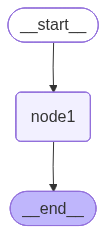

In [44]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

# 1. Define the state
class State(TypedDict):
    state_before_node1: str
    state_after_node1: str

# 2. Define a node (just a function that takes state and returns updated state)
def node1(state):
    print("Passing by node 1")
    state["state_after_node1"] = "Passed by node1"
    return state

# 3. Build the graph
builder = StateGraph(State)
builder.add_node("node1", node1)
builder.add_edge(START, "node1")
builder.add_edge("node1", END)

graph = builder.compile()
visualize_graph(graph)

In [46]:
graph.invoke({"state_before_node1": "State before node 1"})

Passing by node 1


{'state_before_node1': 'State before node 1',
 'state_after_node1': 'Passed by node1'}

### Conditional Routing

We can route between different nodes based on state using `add_conditional_edges()`. The routing function returns the name of the next node.

<img src="./assets-resources/2025-02-10-12-16-57.png" width=50%>

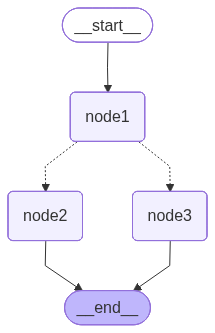

In [47]:
from typing import Literal

class State(TypedDict):
    graph_state: str

def node1(state):
    print("Passing by node 1")
    return state

def node2(state):
    print("Passing by node 2")
    state["graph_state"] = "node 2"
    return state

def node3(state):
    print("Passing by node 3")
    state["graph_state"] = "node 3"
    return state

# Routing function — returns the name of the next node
def decision_node(state) -> Literal["node2", "node3"]:
    if state["graph_state"] == "2":
        return "node2"
    else:
        return "node3"

builder = StateGraph(State)
builder.add_node("node1", node1)
builder.add_node("node2", node2)
builder.add_node("node3", node3)

builder.add_edge(START, "node1")
builder.add_conditional_edges("node1", decision_node)
builder.add_edge("node2", END)
builder.add_edge("node3", END)

graph = builder.compile()
visualize_graph(graph)

In [50]:
# Routes to node2
graph.invoke({"graph_state": "2"})

Passing by node 1
Passing by node 2


{'graph_state': 'node 2'}

In [51]:
# Routes to node3
graph.invoke({"graph_state": "3"})

Passing by node 1
Passing by node 3


{'graph_state': 'node 3'}

---
## 2. Messages & Reducers

In LLM applications, we typically want to maintain a **conversation history** as messages. LangGraph provides special support for this through **reducers** — functions that control how state keys get updated.

### Message Types

LangChain provides standard message types that LangGraph understands:

In [52]:
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, ToolMessage, AnyMessage
from pprint import pprint

messages = [
    SystemMessage(content="You are a helpful assistant."),
    HumanMessage(content="What is LangGraph?"),
    AIMessage(content="LangGraph is a framework for building stateful agents."),
]

for msg in messages:
    print(f"{msg.__class__.__name__}: {msg.content}")

SystemMessage: You are a helpful assistant.
HumanMessage: What is LangGraph?
AIMessage: LangGraph is a framework for building stateful agents.


### The Override Problem

By default in LangGraph, returning a new value for a state key **overrides** the previous value. This means messages get lost!

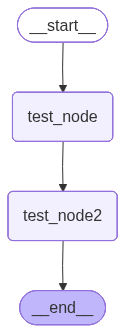

In [53]:
class MessagesStateNaive(TypedDict):
    messages: list[AnyMessage]  # No reducer — default is override!

def my_node(state):
    new_message = HumanMessage(content="message 1", name="Lucas")
    return {"messages": [new_message]}

def my_node2(state):
    new_message = HumanMessage(content="message 2", name="Lucas")
    return {"messages": [new_message]}

workflow = StateGraph(MessagesStateNaive)
workflow.add_node("test_node", my_node)
workflow.add_node("test_node2", my_node2)
workflow.add_edge(START, "test_node")
workflow.add_edge("test_node", "test_node2")
workflow.add_edge("test_node2", END)
graph = workflow.compile()

visualize_graph(graph)

In [55]:
# Only message 2 survives — message 1 was overridden!
result = graph.invoke({"messages": []})
print(f"Number of messages in final state: {len(result['messages'])}")
result

Number of messages in final state: 1


{'messages': [HumanMessage(content='message 2', additional_kwargs={}, response_metadata={}, name='Lucas')]}

### Reducers: `Annotated` + `add_messages`

To **accumulate** messages instead of overriding, we use a **reducer function**. The `add_messages` reducer appends new messages to the existing list.

```python
messages: Annotated[list[AnyMessage], add_messages]  # ← reducer attached!
```

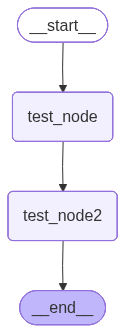

In [56]:
from typing import Annotated
from langgraph.graph.message import add_messages

class MessagesStateWithReducer(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]  # Now messages accumulate!

def my_node(state):
    new_message = HumanMessage(content="message 1", name="Lucas")
    return {"messages": [new_message]}

def my_node2(state):
    new_message = HumanMessage(content="message 2", name="Lucas")
    return {"messages": [new_message]}

workflow = StateGraph(MessagesStateWithReducer)
workflow.add_node("test_node", my_node)
workflow.add_node("test_node2", my_node2)
workflow.add_edge(START, "test_node")
workflow.add_edge("test_node", "test_node2")
workflow.add_edge("test_node2", END)
graph = workflow.compile()

visualize_graph(graph)

In [57]:
# Both messages are preserved!
result = graph.invoke({"messages": []})
print(f"Messages in final state: {len(result['messages'])}")
result

Messages in final state: 2


{'messages': [HumanMessage(content='message 1', additional_kwargs={}, response_metadata={}, name='Lucas', id='d268ca48-bca9-4849-a65c-c87830455667'),
  HumanMessage(content='message 2', additional_kwargs={}, response_metadata={}, name='Lucas', id='5df93583-49d3-4029-bf4b-4ff7e61461d5')]}

### Built-in `MessagesState`

LangGraph provides a pre-built `MessagesState` that already includes the `add_messages` reducer. Use it as a shortcut:

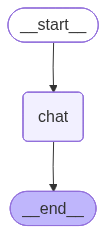

In [60]:
from langgraph.graph import MessagesState
from langchain.chat_models import init_chat_model

llm = init_chat_model(model="gpt-5.4-mini")

def chat_node(state: MessagesState):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

workflow = StateGraph(MessagesState)
workflow.add_node("chat", chat_node)
workflow.add_edge(START, "chat")
workflow.add_edge("chat", END)
app = workflow.compile()

visualize_graph(app)

In [61]:
result = app.invoke({"messages": [HumanMessage("Tell me a joke about graphs.")]})
result["messages"][-1].pretty_print()

================================== Ai Message ==================================

Why did the graph refuse to get into a relationship?

It couldn’t handle all the **points of connection**.


In [62]:
result = app.invoke({"messages": [HumanMessage("Tell the best joke of all time.")]})

In [63]:
result["messages"][-1].pretty_print()

================================== Ai Message ==================================

Why don’t scientists trust atoms?

Because they make up everything.


---
## 3. LLM Workflow Patterns

Now let's explore three essential patterns for building LLM workflows with LangGraph. These patterns are inspired by [Anthropic's article on building effective agents](https://www.anthropic.com/research/building-effective-agents).

<img src="./assets-resources/2025-02-10-20-01-19.png" width=50%>

### Pattern 1: Chaining (Quiz Generation)

A sequential pipeline: **create → review → improve**. The review step uses structured output to decide whether the quiz is good enough.

In [64]:
from pydantic import BaseModel, Field
from langchain.chat_models import init_chat_model

llm = init_chat_model(model="gpt-5.4-mini")

# Structured output for the review step
class ReviewOutput(BaseModel):
    quiz_quality_score: str = Field(description="'APPROVED' or 'TO-REVIEW'")

llm_reviewer = llm.with_structured_output(ReviewOutput)

In [65]:
from typing import Literal

class QuizState(TypedDict):
    input_source: str
    n_questions: str
    quiz: str
    quiz_quality_score: str
    improved_quiz: str


def create_quiz(state: QuizState) -> QuizState:
    n_questions = state["n_questions"]
    input_source = state["input_source"]
    quiz = llm.invoke(f"Create a markdown styled quiz with {n_questions} questions given this content:\n {input_source}")
    return {"quiz": quiz.content}


def review_quiz(state: QuizState) -> QuizState:
    input_source = state["input_source"]
    initial_quiz = state["quiz"]
    review_prompt = f"""You are a reviewer that scores the quality of quizzes based on input content.
    Source: '''{input_source}'''
    Quiz: '''{initial_quiz}'''
    Return 'APPROVED' if the quiz is relevant and comprehensive, 'TO-REVIEW' otherwise."""
    result = llm_reviewer.invoke(review_prompt)
    return {"quiz_quality_score": result.quiz_quality_score}


def route_quiz_feedback(state: QuizState) -> Literal["approved", "improve"]:
    if state["quiz_quality_score"] == "APPROVED":
        return "approved"
    return "improve"


def write_improved_quiz(state: QuizState) -> QuizState:
    input_source = state["input_source"]
    initial_quiz = state["quiz"]
    prompt = f"""Improve this quiz based on the source material.
    Source: '''{input_source}'''
    Current quiz: '''{initial_quiz}'''
    Output ONLY the improved quiz as a numbered list."""
    improved = llm.invoke(prompt)
    return {"improved_quiz": improved.content}

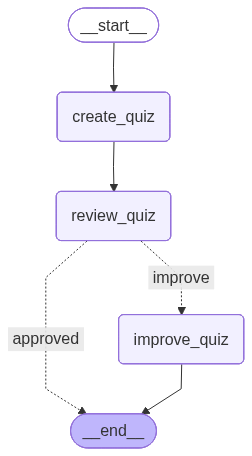

In [66]:
workflow = StateGraph(QuizState)

workflow.add_node("create_quiz", create_quiz)
workflow.add_node("review_quiz", review_quiz)
workflow.add_node("improve_quiz", write_improved_quiz)

workflow.add_edge(START, "create_quiz")
workflow.add_edge("create_quiz", "review_quiz")
workflow.add_conditional_edges("review_quiz", route_quiz_feedback, {"approved": END, "improve": "improve_quiz"})
workflow.add_edge("improve_quiz", END)

graph = workflow.compile()
visualize_graph(graph)

In [67]:
from IPython.display import Markdown

input_source = """LangGraph core concepts:
1. Persistence means keeping state information throughout graph execution.
2. Two fundamental questions: which variables to track, and which artifacts are useful for debugging.
3. Sub-graphs are graphs used as nodes in other graphs.
4. Command is a node that updates state and routes to other nodes."""

output = graph.invoke({"input_source": input_source, "n_questions": "3"})

Markdown(output["quiz"])

# Quiz: LangGraph Core Concepts

## Question 1
What does **persistence** mean in LangGraph?

- A. Saving graphs as files
- B. Keeping state information throughout graph execution
- C. Running graphs faster
- D. Deleting unused variables

---

## Question 2
What are the **two fundamental questions** mentioned in LangGraph core concepts?

- A. Which models to use, and which APIs to call
- B. Which variables to track, and which artifacts are useful for debugging
- C. Which nodes to remove, and which edges to add
- D. Which users can access the graph, and which files to export

---

## Question 3
What is a **Command** in LangGraph?

- A. A graph used inside another graph
- B. A node that updates state and routes to other nodes
- C. A debugging tool for logs only
- D. A variable used to store persistent memory

---

## Answer Key
1. **B**
2. **B**
3. **B**

### Pattern 2: Parallel Execution

Multiple nodes can run in parallel from `START`, then join at a final node. This is useful when you need multiple independent LLM calls that combine into a single output.

In [68]:
class ExplanationState(TypedDict):
    question: str
    analogy: str
    examples: str
    plain_english: str
    technical_definition: str
    full_explanation: str


def generate_analogy(state: ExplanationState) -> ExplanationState:
    question = state["question"]
    output = llm.invoke(f"Explain this by providing an analogy: {question}")
    return {"analogy": output.content}

def generate_example(state: ExplanationState) -> ExplanationState:
    question = state["question"]
    output = llm.invoke(f"Provide 3 examples to demonstrate: {question}")
    return {"examples": output.content}

def explain_plain_english(state: ExplanationState) -> ExplanationState:
    question = state["question"]
    output = llm.invoke(f"Explain in simple plain english in 2 paragraphs: {question}")
    return {"plain_english": output.content}

def explain_technical(state: ExplanationState) -> ExplanationState:
    question = state["question"]
    output = llm.invoke(f"Give a rigorous technical definition in 2 paragraphs: {question}")
    return {"technical_definition": output.content}

def generate_final_explanation(state: ExplanationState) -> ExplanationState:
    full = f"""# Full Explanation\n\n## Analogy\n{state['analogy']}\n\n## Examples\n{state['examples']}\n\n## Plain English\n{state['plain_english']}\n\n## Technical Definition\n{state['technical_definition']}"""
    return {"full_explanation": full}

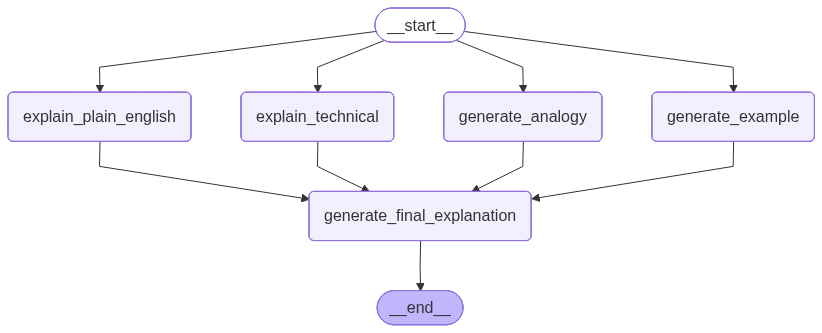

In [69]:
workflow = StateGraph(ExplanationState)

workflow.add_node("generate_analogy", generate_analogy)
workflow.add_node("generate_example", generate_example)
workflow.add_node("explain_plain_english", explain_plain_english)
workflow.add_node("explain_technical", explain_technical)
workflow.add_node("generate_final_explanation", generate_final_explanation)

# All 4 nodes run in parallel from START
workflow.add_edge(START, "generate_analogy")
workflow.add_edge(START, "generate_example")
workflow.add_edge(START, "explain_plain_english")
workflow.add_edge(START, "explain_technical")

# All join at the final node
workflow.add_edge("generate_analogy", "generate_final_explanation")
workflow.add_edge("generate_example", "generate_final_explanation")
workflow.add_edge("explain_plain_english", "generate_final_explanation")
workflow.add_edge("explain_technical", "generate_final_explanation")
workflow.add_edge("generate_final_explanation", END)

graph = workflow.compile()
visualize_graph(graph)

In [70]:
output = graph.invoke({"question": "Explain the concept of self-attention in transformers."})
Markdown(output["full_explanation"])

# Full Explanation

## Analogy
Think of **self-attention** like a person reading a sentence and deciding which words matter most for understanding each word.

### Analogy: a group conversation
Imagine a room full of people, and each person is saying one word from a sentence.

If one person wants to understand their own word, they don’t just listen to the nearest person — they look around the room and ask:

- “Which other words are important to me?”
- “Which words help explain my meaning?”

For example, in the sentence:

**“The animal didn’t cross the road because it was tired.”**

When the model looks at **“it,”** self-attention helps it decide that **“animal”** is likely the word it refers to, not **“road.”**

### What’s happening?
Each word:

1. **Looks at every other word**
2. **Assigns importance scores** to them
3. **Uses the most relevant ones** to build a better understanding of itself

So instead of processing words one by one in isolation, the transformer lets each word “pay attention” to all the others at the same time.

### Simple summary
Self-attention is like each word in a sentence carrying a little flashlight, shining it on the other words that matter most to its meaning.

If you want, I can also give:
- a **visual diagram analogy**
- a **movie scene analogy**
- or a **step-by-step technical explanation**

## Examples
Here are **3 examples** that help explain **self-attention in transformers**:

---

### 1) Understanding a pronoun in a sentence
**Sentence:**  
> “The animal didn’t cross the road because it was tired.”

When the model processes **“it”**, self-attention helps it look back at other words in the sentence, especially **“animal”** and **“road.”**  
It assigns more importance to **“animal”** because that is what “it” refers to.

**Why this matters:**  
Self-attention lets the model decide which words are most relevant to each other, even if they are far apart.

---

### 2) Word meaning based on context
**Sentence:**  
> “I went to the bank to deposit money.”

The word **“bank”** could mean a riverbank or a financial institution.  
Self-attention helps the model pay attention to words like **“deposit”** and **“money,”** making it clear that **“bank”** means a place where you store money.

**Why this matters:**  
Self-attention helps the model understand the meaning of a word from the surrounding context.

---

### 3) Matching related words across a long sentence
**Sentence:**  
> “The book that the student who sat in the back row borrowed was fascinating.”

To understand **“was fascinating,”** the model needs to connect it to **“book,”** not **“student.”**  
Self-attention helps the model link the right words, even in a long and nested sentence.

**Why this matters:**  
Self-attention is good at capturing relationships between words no matter how far apart they are in the sentence.

---

### In simple terms
Self-attention allows each word in a sentence to **look at all the other words** and decide **which ones matter most** for understanding it.

If you want, I can also give you:
- a **visual diagram** of self-attention,
- a **math-based explanation**, or
- a **real-world analogy**.

## Plain English
Self-attention is a way for a transformer model to look at all the words in a sentence and decide which ones are most important to each other. Instead of reading words one by one, the model compares every word with every other word and gives more attention to the words that help explain the meaning. For example, in “The cat chased the mouse because it was hungry,” self-attention helps the model figure out that “it” probably refers to “the cat,” not “the mouse,” because it looks at the whole sentence and sees which words are related.

This is useful because words often depend on other words far away in a sentence, not just the ones next to them. Self-attention lets the model understand context better and keep track of meaning across a whole passage. In simple terms, it is like the model highlighting the most relevant words when trying to understand each word. That is one of the main reasons transformers work so well on language tasks like translation, summarizing, and chat.

## Technical Definition
Self-attention is a parameterized mapping that transforms a sequence of input vectors \(X \in \mathbb{R}^{n \times d मॉडल}\) into a sequence of contextualized output vectors by allowing each position to directly aggregate information from all positions in the same sequence. Given learned projection matrices \(W_Q \in \mathbb{R}^{d_{\text{model}} \times d_k}\), \(W_K \in \mathbb{R}^{d_{\text{model}} \times d_k}\), and \(W_V \in \mathbb{R}^{d_{\text{model}} \times d_v}\), we compute queries, keys, and values as \(Q = XW_Q\), \(K = XW_K\), and \(V = XW_V\). The attention weights are then defined by the scaled dot-product rule
\[
A = \mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right),
\]
where the softmax is applied row-wise, so each row of \(A\) is a probability distribution over source positions. The output of self-attention is
\[
Y = AV,
\]
meaning each output vector \(y_i\) is a convex combination of the value vectors \(v_j\), with coefficients determined by the similarity between query \(q_i\) and keys \(k_j\).

In transformer architectures, self-attention is typically used in multi-head form, where several independent attention mechanisms are computed in parallel with different learned projections, producing outputs that are concatenated and linearly projected. This enables the model to represent different relational subspaces simultaneously, such as syntactic, semantic, or positional dependencies. Because the computation of \(A\) depends on pairwise interactions between all token representations, self-attention has \(O(n^2)\) time and memory complexity in sequence length \(n\), but it provides a direct path for modeling long-range dependencies without recurrence. In causal (autoregressive) transformers, a mask is applied so that position \(i\) may attend only to positions \(j \le i\), preserving the factorization required for left-to-right generation; in bidirectional encoders, no such mask is used, allowing full-sequence contextualization.

### Pattern 3: Routing with Structured Output

An LLM classifies the input and routes to a specialized "expert" node. We use Pydantic's structured output to get reliable routing decisions.

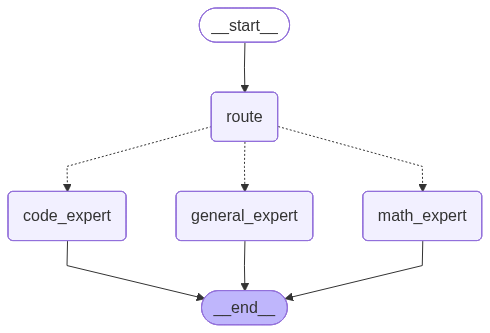

In [71]:
class RoutingState(TypedDict):
    question: str
    category: str | None
    answer: str | None

class QuestionType(BaseModel):
    category: str = Field(description="Category: CODE, MATH, or GENERAL")

llm_classifier = llm.with_structured_output(QuestionType)

# Router: classify the question
def route_question(state: RoutingState):
    response = llm_classifier.invoke(
        f"""Classify this question into exactly ONE category:
        - CODE if about programming/coding
        - MATH if about mathematical calculations
        - GENERAL for general knowledge
        Question: {state['question']}"""
    )
    print(f"Classified as: {response.category}")
    return {"category": response.category}

# Specialized expert nodes
def code_expert(state: RoutingState):
    print("Using code expert!")
    return {"answer": llm.invoke(f"As a coding expert, answer: {state['question']}").content}

def math_expert(state: RoutingState):
    print("Using math expert!")
    return {"answer": llm.invoke(f"As a math expert, solve: {state['question']}").content}

def general_expert(state: RoutingState):
    print("Using general expert!")
    return {"answer": llm.invoke(f"Answer this question: {state['question']}").content}

# Routing logic
def router(state: RoutingState):
    if state["category"] == "CODE":
        return "code_expert"
    elif state["category"] == "MATH":
        return "math_expert"
    return "general_expert"

# Build the graph
workflow = StateGraph(RoutingState)
workflow.add_node("route", route_question)
workflow.add_node("code_expert", code_expert)
workflow.add_node("math_expert", math_expert)
workflow.add_node("general_expert", general_expert)

workflow.add_edge(START, "route")
workflow.add_conditional_edges("route", router, {
    "code_expert": "code_expert",
    "math_expert": "math_expert",
    "general_expert": "general_expert"
})
workflow.add_edge("code_expert", END)
workflow.add_edge("math_expert", END)
workflow.add_edge("general_expert", END)

graph = workflow.compile()
visualize_graph(graph)

In [72]:
graph.invoke({"question": "What is the time complexity of quicksort?", "category": None, "answer": None})

Classified as: CODE
Using code expert!


{'question': 'What is the time complexity of quicksort?',
 'category': 'CODE',
 'answer': 'Quicksort has:\n\n- **Average / best-case time complexity:** **O(n log n)**\n- **Worst-case time complexity:** **O(n²)**\n\n### Why?\n- On average, the pivot splits the array into two roughly equal halves, and there are about **log n** levels of partitioning.\n- Each level processes **n** elements total, giving **n log n**.\n\n### Worst case\n- If the pivot is consistently the smallest or largest element, the partitions become highly unbalanced.\n- Then it behaves like a linear chain of recursive calls, resulting in **O(n²)**.\n\nIf you want, I can also explain **space complexity** or show the recurrence relation.'}

In [73]:
graph.invoke({"question": "What is the integral of x^2?", "category": None, "answer": None})

Classified as: MATH
Using math expert!


{'question': 'What is the integral of x^2?',
 'category': 'MATH',
 'answer': 'The integral of \\(x^2\\) with respect to \\(x\\) is:\n\n\\[\n\\int x^2\\,dx = \\frac{x^3}{3} + C\n\\]\n\nwhere \\(C\\) is the constant of integration.'}

---
## 4. Tool Integration

LLMs can't execute code — but they can generate **tool calls** that describe which function to call with what arguments. LangGraph provides `ToolNode` and `tools_condition` to automate this loop.

### Binding Tools to an LLM

When we `bind_tools` to an LLM, it can now generate structured tool call requests (but doesn't execute them).

In [76]:
from langchain.chat_models import init_chat_model

llm = init_chat_model(model="gpt-5.4-mini")

def sum_2_numbers(a: int, b: int) -> int:
    """Takes 2 arguments and returns their sum."""
    return a + b

math_tools = [sum_2_numbers]
llm_with_tools = llm.bind_tools(math_tools)

# The LLM generates a tool call, but doesn't execute it
output = llm_with_tools.invoke("What is the sum of 10 + 23?")
print("Content:", output.content)
print("Tool calls:", output.tool_calls)

Content: 
Tool calls: [{'name': 'sum_2_numbers', 'args': {'a': 10, 'b': 23}, 'id': 'call_a8NtFaQOd1ZfTr0P5RQePyDU', 'type': 'tool_call'}]


We could execute the tool call manually:

In [77]:
tool_map = {'sum_2_numbers': sum_2_numbers}
func = tool_map[output.tool_calls[0]['name']]
a = output.tool_calls[0]['args']['a']
b = output.tool_calls[0]['args']['b']
print(f"Calling {func.__name__}({a}, {b}) = {func(a, b)}")

Calling sum_2_numbers(10, 23) = 33


### `ToolNode` + `tools_condition`: The Agentic Loop

Instead of manually executing tools, LangGraph provides:
- **`ToolNode`** — A node that automatically executes any tool calls from the LLM
- **`tools_condition`** — A routing function that sends to `ToolNode` if the LLM made tool calls, otherwise goes to `END`

Together they create the **agentic loop**: LLM → Tools → LLM → ... → END

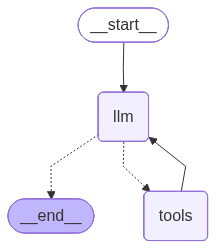

In [83]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition

def sum_2_numbers(a: int, b: int) -> int:
    """Takes 2 arguments and returns their sum."""
    return a + b

tool_node = ToolNode([sum_2_numbers])

def llm_node(state: MessagesState) -> MessagesState:
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

workflow = StateGraph(MessagesState)
workflow.add_node("llm", llm_node)
workflow.add_node("tools", tool_node)

workflow.add_edge(START, "llm")
workflow.add_conditional_edges("llm", tools_condition)  # Routes to 'tools' or END
workflow.add_edge("tools", "llm")  # Loop back to LLM after tool execution

graph = workflow.compile()
visualize_graph(graph)

In [81]:
result = graph.invoke({"messages": ["Sum of 10 and 4? then sum of 34 + 123"]})
for msg in result["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Sum of 10 and 4? then sum of 34 + 123
================================== Ai Message ==================================
Tool Calls:
  sum_2_numbers (call_QlByQeNeRHuOK191CQ5XsWLQ)
 Call ID: call_QlByQeNeRHuOK191CQ5XsWLQ
  Args:
    a: 10
    b: 4
  sum_2_numbers (call_tdWNEMQNaZ5A98Y1QGW2b4Vk)
 Call ID: call_tdWNEMQNaZ5A98Y1QGW2b4Vk
  Args:
    a: 34
    b: 123
================================= Tool Message =================================
Name: sum_2_numbers

14
================================= Tool Message =================================
Name: sum_2_numbers

157
================================== Ai Message ==================================

10 + 4 = 14  
34 + 123 = 157


### Capstone: Chatbot with Web Search

Let's put it all together — a chatbot that can search the web using TavilySearch, built with the same `ToolNode` + `tools_condition` pattern.

In [84]:
_set_env("TAVILY_API_KEY")

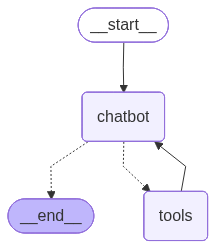

In [87]:
from langchain_tavily import TavilySearch
from langchain.chat_models import init_chat_model

llm = init_chat_model("openai:gpt-5.4-mini")
web_search_tool = TavilySearch(max_results=2)
tools = [web_search_tool]

llm_with_tools = llm.bind_tools(tools)

def chatbot(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

tool_node = ToolNode(tools=tools)

graph_builder = StateGraph(MessagesState)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", tool_node)
graph_builder.add_conditional_edges("chatbot", tools_condition)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

graph = graph_builder.compile()
visualize_graph(graph)

In [88]:
result = graph.invoke({"messages": ["What are the latest news about LangGraph?"]})
result["messages"][-1].pretty_print()

================================== Ai Message ==================================

Here are the latest LangGraph-related updates I found:

- **LangGraph v1.1 released**: The March 2026 LangChain newsletter says `langgraph` **v1.1** is out, with **type-safe streaming**, **type-safe invoke**, and **Pydantic/dataclass coercion**. It’s described as **fully backwards compatible**.
- **LangGraph Platform in beta**: LangChain announced new deployment options for **scalable agent infrastructure** via the **LangGraph Platform**.
- **New Deploy CLI**: They introduced a **`langgraph-cli` Deploy CLI** so you can deploy agents to **LangSmith Deployment** directly from the terminal.
- **Enterprise/NVIDIA integration**: LangChain also announced an enterprise agentic AI platform with NVIDIA, and specifically mentions **LangGraph** as part of the stack for **stateful multi-agent orchestration**, human-in-the-loop flows, and optimizations like parallel and speculative execution.
- **Recent real-world cas

In [94]:
for chunk in graph.stream(
    {"messages": ["What are the latest news about LangGraph?"]},
    stream_mode=["updates", "custom"],
    version="v2",
):
    if chunk["type"] == "updates":
        for node_name, state in chunk["data"].items():
            print(f"Node {node_name} updated: {state}")
    elif chunk["type"] == "custom":
        print(f"Status: {chunk['data']['status']}")

Node chatbot updated: {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 46, 'prompt_tokens': 1277, 'total_tokens': 1323, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1152}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DRfnp0ReZ8JSd143ZHM3ns3Mn5X93', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d6353-9aa2-7292-a279-f223f5020023-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'LangGraph latest news updates', 'search_depth': 'advanced', 'topic': 'news', 'time_range': 'month', 'include_images': False}, 'id': 'call_VkbOmUBucUs1aQXs0RwW2l7G', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1277, 'output_to

---
## Summary

In this notebook we covered the core building blocks of LangGraph:

| Concept | Key API |
|---------|--------|
| State definition | `TypedDict` |
| Graph building | `StateGraph`, `START`, `END` |
| Routing | `add_conditional_edges()` |
| Message accumulation | `Annotated[list, add_messages]` or `MessagesState` |
| Structured output | `llm.with_structured_output(PydanticModel)` |
| Tool integration | `bind_tools()`, `ToolNode`, `tools_condition` |
| Workflow patterns | Chaining, Parallel, Routing |

**Next**: In Notebook 2, we'll build a full ReAct agent with memory persistence.